# Tahap 5: Model Evaluation
**Mata Kuliah:** Penalaran Komputer — SubCPMK-3 Case-Based Reasoning  
**Domain:** Perlindungan Anak  
**Tujuan:** Ukur dan analisis performa retrieval & prediksi secara lengkap

### Alur Notebook:
1. Install & Import
2. Load Semua Artefak
3. Evaluasi Retrieval (Accuracy, Precision, Recall, F1)
4. Evaluasi Prediksi Solution Reuse
5. Perbandingan TF-IDF vs Embedding
6. Analisis Kegagalan (Error Analysis)
7. Visualisasi Performa
8. Simpan Laporan Metrik
9. Ringkasan & Rekomendasi

## Cell 1 — Install Dependencies

## Cell 2 — Import Library

In [1]:
import json
import re
import warnings
import logging
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
from pathlib import Path
from collections import Counter

import joblib
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay
)
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import cross_val_score
from sentence_transformers import SentenceTransformer

warnings.filterwarnings("ignore")
matplotlib.rcParams["figure.dpi"] = 120
matplotlib.rcParams["font.size"]  = 10

print("✅ Library berhasil diimport")

d:\amad\Paper\Tugas\PK\Penalaran-Komputer-Sub-3\PK\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✅ Library berhasil diimport


## Cell 3 — Konfigurasi

In [2]:
from pathlib import Path
import logging

CONFIG = {
    "TOP_K": 3,
    "RANDOM_STATE": 42,
}

# =====================================================
# ROOT PROJECT
# =====================================================
PROJECT_ROOT = Path.cwd().parent

STEP1_DIR = PROJECT_ROOT / "STEP 1"
STEP3_DIR = PROJECT_ROOT / "STEP 3"
STEP4_DIR = PROJECT_ROOT / "STEP 4"

# =====================================================
# DATA
# =====================================================
DATA_PROC = STEP1_DIR / "data" / "processed"
DATA_EVAL = STEP1_DIR / "data" / "eval"

# hasil solution reuse
DATA_RESULT = STEP4_DIR / "data" / "results"

# model retrieval
MODEL_DIR = STEP3_DIR / "models"

# log global project
LOGS_DIR = PROJECT_ROOT / "logs"

LOGS_DIR.mkdir(parents=True, exist_ok=True)

# =====================================================
# LOGGING
# =====================================================
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s | %(levelname)s | %(message)s",
    handlers=[
        logging.FileHandler(
            LOGS_DIR / "evaluation.log",
            encoding="utf-8"
        ),
        logging.StreamHandler()
    ]
)

logger = logging.getLogger(__name__)

print("✅ Konfigurasi selesai")
print("PROJECT_ROOT =", PROJECT_ROOT)
print("DATA_RESULT  =", DATA_RESULT)
print("MODEL_DIR    =", MODEL_DIR)
print("LOGS_DIR     =", LOGS_DIR)

✅ Konfigurasi selesai
PROJECT_ROOT = d:\amad\Paper\Tugas\PK\Penalaran-Komputer-Sub-3
DATA_RESULT  = d:\amad\Paper\Tugas\PK\Penalaran-Komputer-Sub-3\STEP 4\data\results
MODEL_DIR    = d:\amad\Paper\Tugas\PK\Penalaran-Komputer-Sub-3\STEP 3\models
LOGS_DIR     = d:\amad\Paper\Tugas\PK\Penalaran-Komputer-Sub-3\logs


## Cell 4 — Load Semua Artefak

In [3]:
# ── Cases — PENTING: pakai cases_index.csv bukan cases.json ──────────
# cases_index.csv sinkron dengan X_tfidf dan embeddings dari Tahap 3
# Jika pakai cases.json langsung, index DataFrame bisa tidak match
with open(DATA_PROC / "cases.json", encoding="utf-8") as f:
    cases = json.load(f)
df_all = pd.DataFrame(cases)
print(f"✅ cases.json dimuat — {len(df_all)} kasus total")

# Load cases_index (yang dipakai saat Tahap 3 membangun X_tfidf)
cases_index_path = MODEL_DIR / "cases_index.csv"
assert cases_index_path.exists(), "❌ cases_index.csv tidak ada di models/"

df_idx = pd.read_csv(cases_index_path)
print(f"✅ cases_index.csv dimuat — {len(df_idx)} kasus (yang dipakai Tahap 3)")

# Gunakan df yang index-nya sinkron dengan X_tfidf
# Reset index agar mulai dari 0 sesuai baris X_tfidf
df = df_idx.reset_index(drop=True)
print(f"   case_id range: {df['case_id'].iloc[0]} → {df['case_id'].iloc[-1]}")

# ── TF-IDF ──────────────────────────────────────────────────
tfidf   = joblib.load(MODEL_DIR / "tfidf_vectorizer.pkl")
X_tfidf = joblib.load(MODEL_DIR / "tfidf_matrix.pkl")
svm     = joblib.load(MODEL_DIR / "svm_model.pkl")
le      = joblib.load(MODEL_DIR / "label_encoder.pkl")
print(f"✅ TF-IDF + SVM dimuat — matrix: {X_tfidf.shape}")
assert X_tfidf.shape[0] == len(df), \
    f"❌ Mismatch: X_tfidf={X_tfidf.shape[0]} baris, df={len(df)} baris"
print(f"✅ Shape match: {X_tfidf.shape[0]} baris")

# ── Embeddings ───────────────────────────────────────────────
embeddings = np.load(MODEL_DIR / "embeddings.npy")
print(f"✅ Embeddings dimuat — shape: {embeddings.shape}")
assert embeddings.shape[0] == len(df), \
    f"❌ Mismatch: embeddings={embeddings.shape[0]}, df={len(df)}"

ST_MODEL = "sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2"
print(f"\n🔄 Loading SentenceTransformer...")
st_model = SentenceTransformer(ST_MODEL)
print(f"✅ ST model siap")

# ── Predictions dari Tahap 4 ────────────────────────────────
pred_path = DATA_RESULT / "predictions.csv"
if pred_path.exists():
    df_pred = pd.read_csv(pred_path)
    print(f"✅ predictions.csv dimuat — {len(df_pred)} baris")
else:
    df_pred = pd.DataFrame()
    print("⚠️  predictions.csv tidak ditemukan — evaluasi prediksi dilewati")

# ── Queries eval ─────────────────────────────────────────────
queries_path = DATA_EVAL / "queries.json"
if queries_path.exists():
    with open(queries_path, encoding="utf-8") as f:
        queries_eval = json.load(f)
    print(f"✅ queries.json dimuat — {len(queries_eval)} query")
else:
    queries_eval = []
    print("⚠️  queries.json tidak ditemukan")

print(f"\n{'='*50}")
print(f"  Semua artefak sinkron — siap evaluasi")
print(f"  df      : {len(df)} baris")
print(f"  X_tfidf : {X_tfidf.shape}")
print(f"  embed   : {embeddings.shape}")
print(f"{'='*50}")

2026-06-14 00:12:16,840 | INFO | No device provided, using cpu


✅ cases.json dimuat — 44 kasus total
✅ cases_index.csv dimuat — 43 kasus (yang dipakai Tahap 3)
   case_id range: case_047 → case_100
✅ TF-IDF + SVM dimuat — matrix: (43, 3616)
✅ Shape match: 43 baris
✅ Embeddings dimuat — shape: (43, 384)

🔄 Loading SentenceTransformer...


2026-06-14 00:12:17,210 | INFO | HTTP Request: HEAD https://huggingface.co/sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2/resolve/main/modules.json "HTTP/1.1 307 Temporary Redirect"
2026-06-14 00:12:17,242 | INFO | HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2/e8f8c211226b894fcb81acc59f3b34ba3efd5f42/modules.json "HTTP/1.1 200 OK"
2026-06-14 00:12:17,504 | INFO | HTTP Request: HEAD https://huggingface.co/sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2/resolve/main/config_sentence_transformers.json "HTTP/1.1 307 Temporary Redirect"
2026-06-14 00:12:17,505 | WARNING | Warning: You are sending unauthenticated requests to the HF Hub. Please set a HF_TOKEN to enable higher rate limits and faster downloads.
2026-06-14 00:12:17,533 | INFO | HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2/e8f8c211226b894fcb81acc

✅ ST model siap
✅ predictions.csv dimuat — 5 baris
✅ queries.json dimuat — 5 query

  Semua artefak sinkron — siap evaluasi
  df      : 43 baris
  X_tfidf : (43, 3616)
  embed   : (43, 384)


## Cell 5 — Fungsi Pendukung (Retrieve & Preprocessing)

In [4]:
STOPWORDS_ID = set([
    "yang","dan","di","ke","dari","dengan","untuk","pada","dalam",
    "adalah","ini","itu","atau","juga","sudah","oleh","tidak","ada",
    "bahwa","telah","akan","maka","serta","para","kepada","karena",
    "atas","sebagai","dapat","tersebut","sehingga","antara","nomor",
    "halaman","republik","indonesia","mahkamah","pengadilan","agung",
])

def preprocess_teks(teks: str, max_chars: int = 8000) -> str:
    if not teks or not isinstance(teks, str): return ""
    teks = teks[:max_chars].lower()
    teks = re.sub(r"\d+", " ", teks)
    teks = re.sub(r"[^a-z\s]", " ", teks)
    teks = re.sub(r"\s+", " ", teks).strip()
    kata = [k for k in teks.split() if k not in STOPWORDS_ID and len(k) > 2]
    return " ".join(kata)

def buat_teks_representasi(row) -> str:
    bagian = []
    for field in ["pasal_dakwaan","pasal_terbukti","amar_putusan"]:
        val = str(row.get(field,"")).strip()
        if val: bagian.append(val); bagian.append(val)
    for field in ["ringkasan_fakta","barang_bukti","terdakwa"]:
        val = str(row.get(field,"")).strip()
        if val: bagian.append(val)
    teks_penuh = str(row.get("teks_full",""))[:3000]
    if teks_penuh: bagian.append(teks_penuh)
    return " ".join(bagian)

def retrieve(query: str, k: int = 5, mode: str = "tfidf") -> list:
    """Retrieve top-k kasus paling mirip — tanpa field label."""
    query_clean = preprocess_teks(query)
    if not query_clean: return []
    if mode == "tfidf":
        q_vec  = tfidf.transform([query_clean])
        scores = cosine_similarity(q_vec, X_tfidf).flatten()
    else:
        q_emb  = st_model.encode([query], normalize_embeddings=True)
        scores = cosine_similarity(q_emb, embeddings).flatten()
    top_idx = np.argsort(scores)[::-1][:k]
    return [{"case_id": df.iloc[i]["case_id"],
             "score"  : round(float(scores[i]), 4)}
            for i in top_idx]

# Buat kolom teks_repr untuk evaluasi retrieval
if "teks_repr" not in df.columns:
    df["teks_repr"]      = df.apply(buat_teks_representasi, axis=1)
    df["teks_processed"] = df["teks_repr"].apply(preprocess_teks)

print("✅ Fungsi pendukung siap (tanpa label)")
print(f"   df: {len(df)} baris, kolom: {list(df.columns[:5])}...")

✅ Fungsi pendukung siap (tanpa label)
   df: 43 baris, kolom: ['case_id', 'url_detail', 'path_txt', 'no_perkara', 'tanggal_putusan']...


## Cell 6 — Evaluasi Model SVM (Classification)

> Evaluasi SVM sebagai classifier menggunakan cross-validation  
> karena data mungkin terlalu kecil untuk split yang stabil.

In [5]:
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.preprocessing import LabelEncoder

print(f"{'='*55}")
print(f"  EVALUASI SVM — KLASIFIKASI AMAR PUTUSAN")
print(f"{'='*55}\n")

# SVM di Tahap 3 dilatih untuk mengklasifikasikan amar putusan
# Label diambil dari cases_index.csv (output Tahap 3) bukan diinfer ulang
if "label" not in df.columns:
    print("⚠️  Kolom label tidak ada di df — evaluasi SVM dilewati")
    metrics_svm = {"accuracy":0,"precision_macro":0,"recall_macro":0,
                   "f1_macro":0,"n_splits":0,"n_samples":0}
    df_svm = df.copy()
    le_eval = LabelEncoder()
    y_all = np.zeros(len(df), dtype=int)
    idx_all = df.index.tolist()
    X_all = X_tfidf[idx_all]
    y_pred_all = y_all
else:
    label_counts = df["label"].value_counts()
    label_valid  = label_counts[label_counts >= 2].index.tolist()

    print(f"  Distribusi label di corpus:")
    for l, cnt in label_counts.items():
        bar = "█" * int(cnt * 20 // len(df)) + "░" * (20 - int(cnt * 20 // len(df)))
        print(f"    {l:<12} [{bar}] {cnt} ({cnt/len(df):.0%})")

    if svm is None:
        print("\n⚠️  SVM tidak tersedia — evaluasi SVM dilewati")
        metrics_svm = {"accuracy":0,"precision_macro":0,"recall_macro":0,
                       "f1_macro":0,"n_splits":0,"n_samples":0}
        df_svm = df.copy()
        le_eval = LabelEncoder()
        y_all = le_eval.fit_transform(df_svm["label"])
        idx_all = df_svm.index.tolist()
        X_all = X_tfidf[idx_all]
        y_pred_all = y_all

    elif len(label_valid) < 2 or (label_valid and label_counts[label_valid].min() < 2):
        print("\n⚠️  Data terlalu sedikit untuk cross-validation — pakai train set")
        df_svm  = df[df["label"].isin(label_valid)].copy() if label_valid else df.copy()
        le_eval = LabelEncoder()
        y_all   = le_eval.fit_transform(df_svm["label"])
        idx_all = df_svm.index.tolist()
        X_all   = X_tfidf[idx_all]

        if len(set(y_all)) >= 2:
            svm.fit(X_all, y_all)
            y_pred_all = svm.predict(X_all)
            from sklearn.metrics import precision_score, recall_score, f1_score
            metrics_svm = {
                "accuracy"        : round(accuracy_score(y_all, y_pred_all), 4),
                "precision_macro" : round(precision_score(y_all, y_pred_all,
                                          average="macro", zero_division=0), 4),
                "recall_macro"    : round(recall_score(y_all, y_pred_all,
                                          average="macro", zero_division=0), 4),
                "f1_macro"        : round(f1_score(y_all, y_pred_all,
                                          average="macro", zero_division=0), 4),
                "n_splits": 0, "n_samples": len(df_svm),
            }
            print(f"\n  Accuracy (train) : {metrics_svm['accuracy']:.4f}")
            print(f"  F1 (macro)       : {metrics_svm['f1_macro']:.4f}")
            print(f"\n  Classification Report:")
            print(classification_report(y_all, y_pred_all,
                                         target_names=le_eval.classes_, zero_division=0))
        else:
            y_pred_all = y_all
            metrics_svm = {"accuracy":0,"precision_macro":0,"recall_macro":0,
                           "f1_macro":0,"n_splits":0,"n_samples":len(df_svm)}
            print("  ⚠️  Hanya 1 label — evaluasi SVM tidak bermakna")

    else:
        df_svm  = df[df["label"].isin(label_valid)].copy()
        le_eval = LabelEncoder()
        y_all   = le_eval.fit_transform(df_svm["label"])
        idx_all = df_svm.index.tolist()
        X_all   = X_tfidf[idx_all]

        n_splits = min(5, int(label_counts[label_valid].min()))
        n_splits = max(2, n_splits)
        print(f"\n  Cross-validation: {n_splits}-fold pada {len(df_svm)} sampel")

        cv = StratifiedKFold(n_splits=n_splits, shuffle=True,
                             random_state=CONFIG["RANDOM_STATE"])
        cv_results = cross_validate(
            svm, X_all, y_all, cv=cv,
            scoring=["accuracy","precision_macro","recall_macro","f1_macro"],
            return_train_score=False,
        )
        metrics_svm = {
            "accuracy"        : round(cv_results["test_accuracy"].mean(), 4),
            "precision_macro" : round(cv_results["test_precision_macro"].mean(), 4),
            "recall_macro"    : round(cv_results["test_recall_macro"].mean(), 4),
            "f1_macro"        : round(cv_results["test_f1_macro"].mean(), 4),
            "n_splits": n_splits, "n_samples": len(df_svm),
        }
        print(f"\n  {'Accuracy':<20}: {metrics_svm['accuracy']:.4f}")
        print(f"  {'Precision (macro)':<20}: {metrics_svm['precision_macro']:.4f}")
        print(f"  {'Recall (macro)':<20}: {metrics_svm['recall_macro']:.4f}")
        print(f"  {'F1 (macro)':<20}: {metrics_svm['f1_macro']:.4f}")

        svm.fit(X_all, y_all)
        y_pred_all = svm.predict(X_all)
        print(f"\n  Classification Report (train):")
        print(classification_report(y_all, y_pred_all,
                                     target_names=le_eval.classes_, zero_division=0))

logger.info(f"SVM eval: acc={metrics_svm['accuracy']}, f1={metrics_svm['f1_macro']}")

2026-06-14 00:12:25,019 | INFO | SVM eval: acc=0.9068, f1=0.4756


  EVALUASI SVM — KLASIFIKASI AMAR PUTUSAN

  Distribusi label di corpus:
    terbukti     [██████████████████░░] 39 (91%)
    lainnya      [█░░░░░░░░░░░░░░░░░░░] 4 (9%)

  Cross-validation: 4-fold pada 43 sampel

  Accuracy            : 0.9068
  Precision (macro)   : 0.4534
  Recall (macro)      : 0.5000
  F1 (macro)          : 0.4756

  Classification Report (train):
              precision    recall  f1-score   support

     lainnya       1.00      1.00      1.00         4
    terbukti       1.00      1.00      1.00        39

    accuracy                           1.00        43
   macro avg       1.00      1.00      1.00        43
weighted avg       1.00      1.00      1.00        43



## Cell 7 — Evaluasi Retrieval: Precision@K, Recall@K, F1@K

> Evaluasi retrieval menggunakan **leave-one-out**:  
> setiap dokumen dijadikan query, lalu cek apakah dokumen dengan  
> label sama muncul di top-K hasil.

In [6]:
def eval_retrieval_leave_one_out(mode: str = "tfidf", k: int = 5) -> dict:
    """
    Leave-one-out evaluation untuk retrieval berbasis similarity score.

    Karena tidak ada ground-truth label eksternal, relevansi diukur
    dengan threshold cosine similarity >= 0.05.

    Untuk setiap dokumen i:
      - Jadikan teks_repr sebagai query
      - Ambil top-k dari sisa dokumen (kecuali diri sendiri)
      - Dokumen relevan jika score >= threshold
    """
    THRESHOLD = 0.05
    precision_list, recall_list, f1_list = [], [], []

    for i, row in df.iterrows():
        teks_q = str(row.get("teks_repr", row.get("teks_full", "")))
        if not teks_q.strip():
            continue

        # Retrieve top-k (termasuk diri sendiri mungkin)
        hasil = retrieve(teks_q, k=k+1, mode=mode)
        # Buang diri sendiri
        hasil = [h for h in hasil if h["case_id"] != row["case_id"]][:k]
        if not hasil:
            continue

        # Relevan = score >= threshold
        n_relevan_topk  = sum(1 for h in hasil if h["score"] >= THRESHOLD)
        n_relevan_total = sum(
            1 for _, r in df.iterrows()
            if r["case_id"] != row["case_id"]
            and retrieve(str(r.get("teks_repr","")), k=1, mode=mode)
            and retrieve(str(r.get("teks_repr","")), k=1, mode=mode)[0]["score"] >= THRESHOLD
        ) or 1  # hindari div-by-zero

        precision = n_relevan_topk / len(hasil)
        recall    = n_relevan_topk / min(n_relevan_total, k)
        f1        = (2 * precision * recall / (precision + recall)
                     if (precision + recall) > 0 else 0)

        precision_list.append(precision)
        recall_list.append(recall)
        f1_list.append(f1)

    if not precision_list:
        return {"mode": mode, "k": k, "n_queries": 0,
                "precision": 0, "recall": 0, "f1": 0,
                "precision_std": 0, "recall_std": 0, "f1_std": 0}

    return {
        "mode"         : mode,
        "k"            : k,
        "threshold"    : THRESHOLD,
        "n_queries"    : len(precision_list),
        "precision"    : round(float(np.mean(precision_list)), 4),
        "recall"       : round(float(np.mean(recall_list)), 4),
        "f1"           : round(float(np.mean(f1_list)), 4),
        "precision_std": round(float(np.std(precision_list)), 4),
        "recall_std"   : round(float(np.std(recall_list)), 4),
        "f1_std"       : round(float(np.std(f1_list)), 4),
    }


print("🔄 Evaluasi retrieval TF-IDF...")
metrics_tfidf = eval_retrieval_leave_one_out(mode="tfidf",     k=CONFIG["TOP_K"])

print("🔄 Evaluasi retrieval Embedding...")
metrics_embed = eval_retrieval_leave_one_out(mode="embedding", k=CONFIG["TOP_K"])

print(f"\n{'='*60}")
print(f"  EVALUASI RETRIEVAL Leave-One-Out @ K={CONFIG['TOP_K']}")
print(f"  (Relevan = cosine similarity >= {metrics_tfidf['threshold']})")
print(f"{'='*60}")
print(f"  {'Metrik':<22} {'TF-IDF':>10} {'Embedding':>12}")
print(f"  {'─'*48}")
for m in ["precision","recall","f1"]:
    print(f"  {m.capitalize():<22} {metrics_tfidf[m]:>10.4f} {metrics_embed[m]:>12.4f}")
print(f"  {'─'*48}")
print(f"  {'N queries':<22} {metrics_tfidf['n_queries']:>10} {metrics_embed['n_queries']:>12}")
print(f"{'='*60}")

logger.info(f"Retrieval TF-IDF: P={metrics_tfidf['precision']}, F1={metrics_tfidf['f1']}")
logger.info(f"Retrieval Embed : P={metrics_embed['precision']}, F1={metrics_embed['f1']}")

🔄 Evaluasi retrieval TF-IDF...
🔄 Evaluasi retrieval Embedding...


Batches: 100%|██████████| 1/1 [00:00<00:00, 48.23it/s]
2026-06-14 00:14:24,445 | INFO | Retrieval TF-IDF: P=0.9767, F1=0.9767
2026-06-14 00:14:24,446 | INFO | Retrieval Embed : P=1.0, F1=1.0



  EVALUASI RETRIEVAL Leave-One-Out @ K=3
  (Relevan = cosine similarity >= 0.05)
  Metrik                     TF-IDF    Embedding
  ────────────────────────────────────────────────
  Precision                  0.9767       1.0000
  Recall                     0.9767       1.0000
  F1                         0.9767       1.0000
  ────────────────────────────────────────────────
  N queries                      43           43


## Cell 8 — Evaluasi Prediksi Solution Reuse

In [7]:
if df_pred.empty:
    print("⚠️  predictions.csv kosong — jalankan Tahap 4 terlebih dahulu")
    metrics_prediksi = []
else:
    print(f"{'='*55}")
    print(f"  EVALUASI PREDIKSI SOLUTION REUSE")
    print(f"{'='*55}")
    print(f"  Kolom tersedia: {list(df_pred.columns)}\n")

    # Cek apakah ada kolom predicted_solution dan amar_sebenarnya
    has_solution  = "predicted_solution" in df_pred.columns
    has_actual    = "amar_sebenarnya"    in df_pred.columns
    has_top5      = "top_5_case_ids"     in df_pred.columns

    print(f"  ✅ predicted_solution : {has_solution}")
    print(f"  ✅ amar_sebenarnya    : {has_actual}")
    print(f"  ✅ top_5_case_ids     : {has_top5}")

    # Evaluasi coverage: berapa prediksi yang tidak kosong
    if has_solution:
        n_terisi  = df_pred["predicted_solution"].astype(str).str.strip().ne("").sum()
        n_kosong  = len(df_pred) - n_terisi
        coverage  = n_terisi / len(df_pred) if len(df_pred) else 0
        print(f"\n  Coverage prediksi:")
        print(f"    Terisi  : {n_terisi}/{len(df_pred)} ({coverage:.0%})")
        print(f"    Kosong  : {n_kosong}")

    # Evaluasi kualitas: avg similarity score top-1
    if has_top5 and "top_5_scores" in df_pred.columns:
        avg_top1_score = df_pred["top_5_scores"].apply(
            lambda x: float(str(x).split(",")[0].strip()) if pd.notna(x) and str(x).strip() else 0
        ).mean()
        print(f"\n  Avg similarity score (top-1) : {avg_top1_score:.4f}")

    # Preview hasil prediksi vs actual
    if has_solution and has_actual:
        print(f"\n  Preview prediksi vs aktual:")
        print(f"  {'─'*55}")
        for _, row in df_pred.iterrows():
            print(f"  [{row['query_id']}]")
            print(f"    Predicted : {str(row['predicted_solution'])[:80]}")
            print(f"    Aktual    : {str(row['amar_sebenarnya'])[:80]}")
            print()

    # Simpan metrik coverage untuk laporan
    metrics_prediksi = [{
        "nama"              : "Solution Reuse",
        "coverage"          : round(coverage, 4) if has_solution else 0,
        "n_prediksi"        : len(df_pred),
        "n_terisi"          : n_terisi if has_solution else 0,
        "avg_top1_score"    : round(avg_top1_score, 4) if has_top5 and "top_5_scores" in df_pred.columns else 0,
    }]

    logger.info(f"Solution Reuse coverage: {coverage:.2%}")

2026-06-14 00:14:24,469 | INFO | Solution Reuse coverage: 100.00%


  EVALUASI PREDIKSI SOLUTION REUSE
  Kolom tersedia: ['query_id', 'query_text', 'predicted_solution', 'predicted_pasal', 'predicted_vonis', 'top_5_case_ids', 'top_5_scores', 'best_case_id', 'best_score', 'amar_sebenarnya', 'pasal_sebenarnya', 'groq_summary']

  ✅ predicted_solution : True
  ✅ amar_sebenarnya    : True
  ✅ top_5_case_ids     : True

  Coverage prediksi:
    Terisi  : 5/5 (100%)
    Kosong  : 0

  Avg similarity score (top-1) : 0.1817

  Preview prediksi vs aktual:
  ───────────────────────────────────────────────────────
  [demo_001]
    Predicted : terbukti secara sah dan meyakinkan bersalah melakukan tindak pidana Anak yang Me
    Aktual    : Menjatuhkan pidana penjara dan pelatihan kerja

  [demo_002]
    Predicted : terbukti secara sah dan meyakinkan bersalah melakukan tindak pidana “didepan umu
    Aktual    : Menjatuhkan pidana penjara dengan masa percobaan

  [demo_003]
    Predicted : terbukti secara sah dan menyakinkan bersalah melakukan Tindak Pidana “Penyalah

## Cell 9 — Confusion Matrix SVM

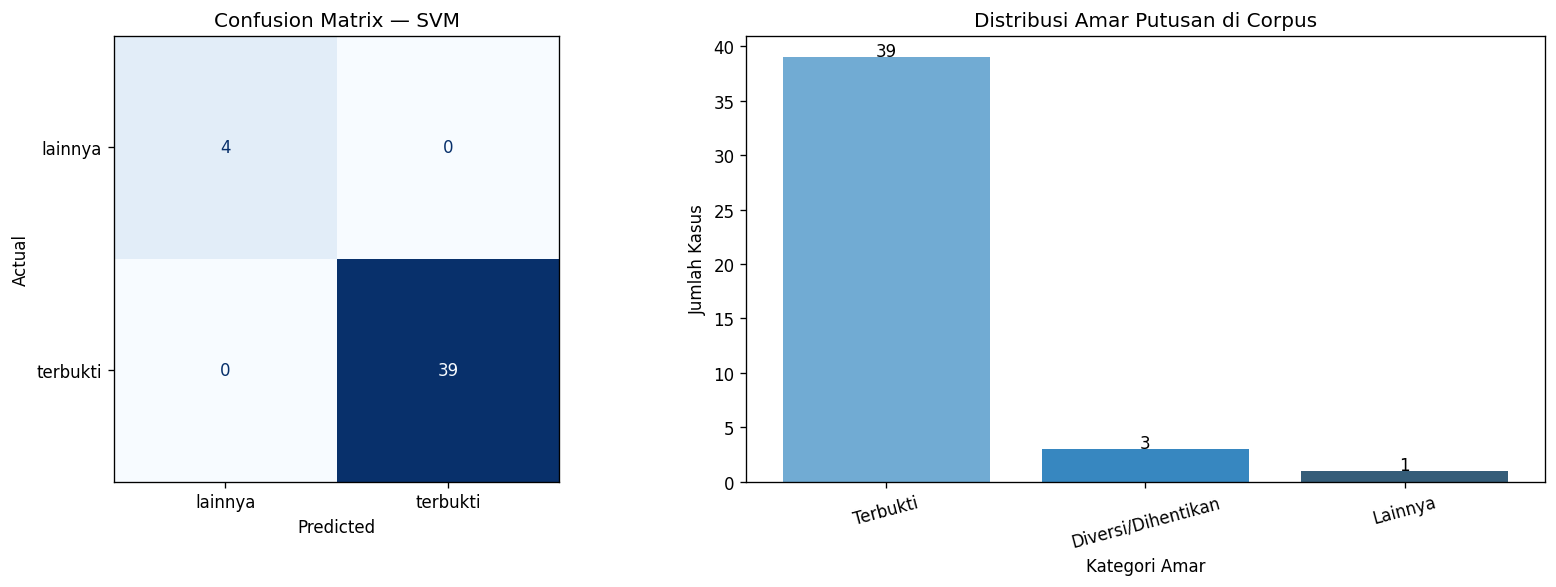

💾 Plot disimpan: d:\amad\Paper\Tugas\PK\Penalaran-Komputer-Sub-3\STEP 1\data\eval\plot_confusion_matrix.png


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Plot 1: Confusion Matrix SVM (jika tersedia) ───────────
if "le_eval" in dir() and "y_all" in dir() and "y_pred_all" in dir() and metrics_svm["accuracy"] > 0:
    cm_svm = confusion_matrix(y_all, y_pred_all)
    disp   = ConfusionMatrixDisplay(confusion_matrix=cm_svm,
                                     display_labels=le_eval.classes_)
    disp.plot(ax=axes[0], colorbar=False, cmap="Blues")
    axes[0].set_title("Confusion Matrix — SVM")
    axes[0].set_xlabel("Predicted")
    axes[0].set_ylabel("Actual")
else:
    axes[0].text(0.5, 0.5, "SVM tidak tersedia\natau hanya 1 label",
                 ha="center", va="center", fontsize=12, color="gray")
    axes[0].set_title("Confusion Matrix — SVM (N/A)")
    axes[0].axis("off")

# ── Plot 2: Distribusi amar_putusan di corpus ──────────────
# Ganti distribusi label dengan distribusi amar_putusan yang lebih informatif
amar_list = df["amar_putusan"].astype(str).str.strip()
amar_list = amar_list[amar_list != ""]

if not amar_list.empty:
    # Kategorikan berdasarkan kata kunci
    def kategori_amar(amar):
        a = amar.lower()
        if any(k in a for k in ["bebas","tidak terbukti"]): return "Bebas"
        elif any(k in a for k in ["lepas","tuntutan"]):     return "Lepas"
        elif any(k in a for k in ["pidana","penjara","denda","terbukti"]): return "Terbukti"
        elif any(k in a for k in ["diversi","kesepakatan","menghentikan"]): return "Diversi/Dihentikan"
        return "Lainnya"

    kategori_dist = amar_list.apply(kategori_amar).value_counts()
    axes[1].bar(kategori_dist.index, kategori_dist.values,
                color=sns.color_palette("Blues_d", len(kategori_dist)))
    axes[1].set_title("Distribusi Amar Putusan di Corpus")
    axes[1].set_xlabel("Kategori Amar")
    axes[1].set_ylabel("Jumlah Kasus")
    axes[1].tick_params(axis="x", rotation=15)
    for i, v in enumerate(kategori_dist.values):
        axes[1].text(i, v + 0.1, str(v), ha="center", fontsize=10)
else:
    axes[1].text(0.5, 0.5, "Amar putusan kosong\n(teks belum terekstrak)",
                 ha="center", va="center", fontsize=11, color="gray")
    axes[1].set_title("Distribusi Amar Putusan (kosong)")
    axes[1].axis("off")

plt.tight_layout()
plt.savefig(DATA_EVAL / "plot_confusion_matrix.png", dpi=120, bbox_inches="tight")
plt.show()
print(f"💾 Plot disimpan: {DATA_EVAL / 'plot_confusion_matrix.png'}")

## Cell 10 — Perbandingan TF-IDF vs Embedding

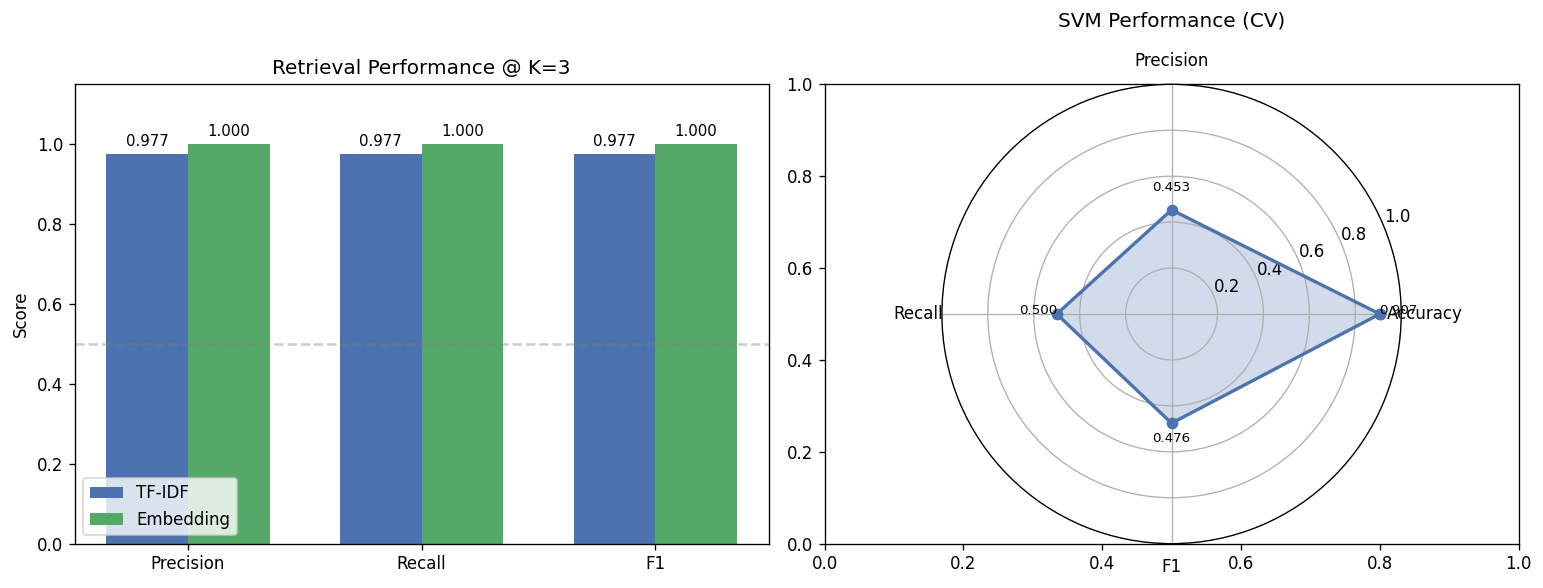

💾 Plot disimpan: d:\amad\Paper\Tugas\PK\Penalaran-Komputer-Sub-3\STEP 1\data\eval\plot_perbandingan_model.png


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

metrik_names = ["Precision", "Recall", "F1"]
vals_tfidf   = [metrics_tfidf["precision"], metrics_tfidf["recall"], metrics_tfidf["f1"]]
vals_embed   = [metrics_embed["precision"], metrics_embed["recall"], metrics_embed["f1"]]

x = np.arange(len(metrik_names))
w = 0.35

# ── Bar chart perbandingan ──────────────────────────────────
bars1 = axes[0].bar(x - w/2, vals_tfidf, w, label="TF-IDF",    color="#4C72B0")
bars2 = axes[0].bar(x + w/2, vals_embed, w, label="Embedding", color="#55A868")

axes[0].set_title(f"Retrieval Performance @ K={CONFIG['TOP_K']}")
axes[0].set_xticks(x)
axes[0].set_xticklabels(metrik_names)
axes[0].set_ylim(0, 1.15)
axes[0].set_ylabel("Score")
axes[0].legend()
axes[0].axhline(y=0.5, color="gray", linestyle="--", alpha=0.4)

for bar in bars1:
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                 f"{bar.get_height():.3f}", ha="center", fontsize=9)
for bar in bars2:
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                 f"{bar.get_height():.3f}", ha="center", fontsize=9)

# ── Radar chart SVM metrics ─────────────────────────────────
svm_metrik = [metrics_svm["accuracy"], metrics_svm["precision_macro"],
              metrics_svm["recall_macro"], metrics_svm["f1_macro"]]
svm_labels = ["Accuracy", "Precision", "Recall", "F1"]

theta  = np.linspace(0, 2*np.pi, len(svm_labels), endpoint=False).tolist()
vals_r = svm_metrik + [svm_metrik[0]]
theta += [theta[0]]

ax2 = plt.subplot(122, polar=True)
ax2.plot(theta, vals_r, "o-", linewidth=2, color="#4C72B0")
ax2.fill(theta, vals_r, alpha=0.25, color="#4C72B0")
ax2.set_xticks(theta[:-1])
ax2.set_xticklabels(svm_labels, fontsize=10)
ax2.set_ylim(0, 1)
ax2.set_title("SVM Performance (CV)", pad=15)
for angle, val in zip(theta[:-1], vals_r[:-1]):
    ax2.text(angle, val + 0.08, f"{val:.3f}", ha="center", fontsize=8)

plt.tight_layout()
plt.savefig(DATA_EVAL / "plot_perbandingan_model.png", dpi=120, bbox_inches="tight")
plt.show()
print(f"💾 Plot disimpan: {DATA_EVAL / 'plot_perbandingan_model.png'}")

## Cell 11 — Analisis Kegagalan (Error Analysis)

> Identifikasi pola kasus yang sering salah diklasifikasi  
> dan berikan rekomendasi perbaikan.

In [10]:
print(f"{'='*60}")
print(f"  ANALISIS KEGAGALAN — ERROR ANALYSIS")
print(f"{'='*60}\n")

# ── Analisis SVM (jika tersedia) ──────────────────────────
if "y_all" in dir() and "y_pred_all" in dir() and "le_eval" in dir() and metrics_svm["accuracy"] > 0:
    salah_svm = []
    for i, (true, pred) in enumerate(zip(y_all, y_pred_all)):
        if true != pred:
            row = df_svm.iloc[i]
            salah_svm.append({
                "case_id"       : row["case_id"],
                "amar_benar"    : le_eval.inverse_transform([true])[0],
                "amar_pred"     : le_eval.inverse_transform([pred])[0],
                "amar_putusan"  : str(row.get("amar_putusan",""))[:100],
                "jumlah_kata"   : row.get("jumlah_kata", 0),
                "n_kata_kunci"  : row.get("n_kata_kunci_pa", 0),
            })

    df_salah = pd.DataFrame(salah_svm)
    print(f"  Total kasus salah klasifikasi (SVM) : {len(df_salah)} / {len(y_all)}")
    print(f"  Error rate                          : {len(df_salah)/len(y_all):.2%}\n")

    if not df_salah.empty:
        print(f"  Pola kesalahan:")
        for _, r in df_salah.iterrows():
            print(f"    {r['case_id']}: {r['amar_benar']} → {r['amar_pred']}")
            print(f"      amar: {r['amar_putusan'][:80]}")
        print(f"\n  Statistik kasus salah:")
        print(f"    Avg kata    : {df_salah['jumlah_kata'].mean():.0f}")
        print(f"    Avg kk_PA   : {df_salah['n_kata_kunci'].mean():.1f}")
        print(f"\n  Kemungkinan penyebab:")
        for _, r in df_salah.iterrows():
            amar = str(r["amar_putusan"]).lower()
            if len(amar) < 30:
                print(f"    [{r['case_id']}] Amar kosong/pendek → metadata tidak terekstrak")
            elif r["n_kata_kunci"] == 0:
                print(f"    [{r['case_id']}] Tidak ada kata kunci PA → mungkin di luar domain")
            elif r["jumlah_kata"] < 300:
                print(f"    [{r['case_id']}] Teks pendek ({r['jumlah_kata']} kata) → OCR kurang")
            else:
                print(f"    [{r['case_id']}] Ambiguitas amar — sulit dibedakan antar kategori")
    else:
        print("  ✅ Tidak ada kesalahan klasifikasi pada train set")
        df_salah = pd.DataFrame()
else:
    print("  ⚠️  Evaluasi SVM tidak tersedia — error analysis SVM dilewati")
    df_salah = pd.DataFrame()

# ── Analisis Retrieval Rejection ───────────────────────────
print(f"\n{'─'*55}")
print(f"  ANALISIS REJECTION RETRIEVAL")
print(f"  (Rejection = kasus dengan max similarity < 0.05)")
print(f"{'─'*55}")

skor_rendah = []
for i, row in df.iterrows():
    teks = str(row.get("teks_repr", row.get("teks_full","")))
    hasil = retrieve(teks, k=2, mode="tfidf")
    hasil = [h for h in hasil if h["case_id"] != row["case_id"]]
    if hasil and hasil[0]["score"] < 0.05:
        skor_rendah.append({
            "case_id"  : row["case_id"],
            "max_score": hasil[0]["score"],
            "amar"     : str(row.get("amar_putusan",""))[:60],
        })

print(f"  Kasus rejection   : {len(skor_rendah)} / {len(df)}")
if skor_rendah:
    for s in skor_rendah[:5]:
        print(f"    {s['case_id']}: score={s['max_score']:.4f} | {s['amar']}")
    print(f"  Rekomendasi: kasus ini mungkin teks terlalu pendek atau OCR gagal.")
else:
    print(f"  ✅ Tidak ada kasus rejection — semua kasus punya similarity cukup")

  ANALISIS KEGAGALAN — ERROR ANALYSIS

  Total kasus salah klasifikasi (SVM) : 0 / 43
  Error rate                          : 0.00%

  ✅ Tidak ada kesalahan klasifikasi pada train set

───────────────────────────────────────────────────────
  ANALISIS REJECTION RETRIEVAL
  (Rejection = kasus dengan max similarity < 0.05)
───────────────────────────────────────────────────────
  Kasus rejection   : 1 / 43
    case_086: score=0.0444 | nan
  Rekomendasi: kasus ini mungkin teks terlalu pendek atau OCR gagal.


## Cell 12 — Rekomendasi Perbaikan

In [11]:
print(f"{'='*60}")
print(f"  REKOMENDASI PERBAIKAN MODEL")
print(f"{'='*60}\n")

f1_tfidf     = metrics_tfidf["f1"]
f1_embed     = metrics_embed["f1"]
mode_terbaik = "TF-IDF" if f1_tfidf >= f1_embed else "Embedding"

rekomendasi = []

# 1. Mode retrieval terbaik
rekomendasi.append({
    "aspek"  : "Mode Retrieval",
    "temuan" : f"TF-IDF F1={f1_tfidf:.3f}, Embedding F1={f1_embed:.3f}",
    "saran"  : f"Gunakan {mode_terbaik} sebagai mode utama. "
               f"{'Embedding lebih akurat untuk teks panjang.' if mode_terbaik == 'Embedding' else 'TF-IDF efisien untuk corpus ini.'}"
})

# 2. Ukuran corpus
if len(df) < 50:
    rekomendasi.append({
        "aspek"  : "Ukuran Corpus",
        "temuan" : f"Hanya {len(df)} dokumen",
        "saran"  : "Tambah minimal 50+ dokumen. Dengan dataset kecil metrik "
                   "cenderung tidak stabil dan tidak representatif."
    })

# 3. Kualitas amar putusan (bukan label)
pct_amar_kosong = (df["amar_putusan"].astype(str).str.strip() == "").mean()
if pct_amar_kosong > 0.3:
    rekomendasi.append({
        "aspek"  : "Amar Putusan Kosong",
        "temuan" : f"{pct_amar_kosong:.0%} dokumen tidak ada amar putusan",
        "saran"  : "Perbaiki OCR di Tahap 1 atau perkuat regex di Tahap 2 "
                   "untuk menangkap bagian MENGADILI dari putusan."
    })

# 4. Rejection rate
rejection_rate = len(skor_rendah) / len(df) if len(df) else 0
if rejection_rate > 0.2:
    rekomendasi.append({
        "aspek"  : "Rejection Rate",
        "temuan" : f"{rejection_rate:.0%} kasus similarity rendah",
        "saran"  : "Banyak teks yang terlalu pendek akibat OCR tidak sempurna. "
                   "Pertimbangkan augmentasi teks dari metadata (judul, no_perkara)."
    })

# 5. SVM performance
if metrics_svm["f1_macro"] < 0.5 and metrics_svm["n_samples"] > 0:
    rekomendasi.append({
        "aspek"  : "SVM F1 Rendah",
        "temuan" : f"F1={metrics_svm['f1_macro']:.3f}",
        "saran"  : "Coba Naive Bayes (lebih stabil untuk dataset kecil), "
                   "atau tuning C parameter di LinearSVC."
    })

print(f"  {'No':<4} {'Aspek':<25} {'Temuan'}")
print(f"  {'─'*65}")
for i, r in enumerate(rekomendasi, 1):
    print(f"  {i:<4} {r['aspek']:<25} {r['temuan'][:30]}")
    print(f"       → {r['saran']}")
    print()

if not rekomendasi:
    print("  ✅ Tidak ada isu kritis — model sudah cukup baik!")

  REKOMENDASI PERBAIKAN MODEL

  No   Aspek                     Temuan
  ─────────────────────────────────────────────────────────────────
  1    Mode Retrieval            TF-IDF F1=0.977, Embedding F1=
       → Gunakan Embedding sebagai mode utama. Embedding lebih akurat untuk teks panjang.

  2    Ukuran Corpus             Hanya 43 dokumen
       → Tambah minimal 50+ dokumen. Dengan dataset kecil metrik cenderung tidak stabil dan tidak representatif.

  3    SVM F1 Rendah             F1=0.476
       → Coba Naive Bayes (lebih stabil untuk dataset kecil), atau tuning C parameter di LinearSVC.



## Cell 13 — Simpan Laporan Metrik Lengkap

In [12]:
laporan = {
    "svm_classification"  : metrics_svm,
    "retrieval_tfidf"     : metrics_tfidf,
    "retrieval_embedding" : metrics_embed,
    "mode_terbaik"        : mode_terbaik,
    "n_kasus_corpus"      : len(df),
    "distribusi_amar"     : df["amar_putusan"].astype(str).str.strip().ne("").sum(),
    "pct_amar_kosong"     : round(pct_amar_kosong, 4),
    "rejection_rate"      : round(rejection_rate, 4),
    "error_analysis"      : {
        "n_salah_svm"  : len(df_salah),
        "error_rate"   : round(len(df_salah)/len(y_all), 4) if "y_all" in dir() and len(y_all) > 0 else 0,
        "n_rejection"  : len(skor_rendah),
    },
    "rekomendasi" : rekomendasi,
}

if not df_pred.empty and "metrics_prediksi" in dir():
    laporan["prediksi_solution_reuse"] = metrics_prediksi

# ── Simpan file output ──────────────────────────────────────
retrieval_metrics_path = DATA_EVAL / "retrieval_metrics.csv"
pd.DataFrame([metrics_tfidf, metrics_embed]).to_csv(
    retrieval_metrics_path, index=False)
print(f"✅ retrieval_metrics.csv → {retrieval_metrics_path}")

if not df_pred.empty and "metrics_prediksi" in dir() and metrics_prediksi:
    pred_metrics_path = DATA_EVAL / "prediction_metrics.csv"
    pd.DataFrame(metrics_prediksi).to_csv(pred_metrics_path, index=False)
    print(f"✅ prediction_metrics.csv → {pred_metrics_path}")

full_report_path = DATA_EVAL / "full_report.json"
with open(full_report_path, "w", encoding="utf-8") as f:
    json.dump(laporan, f, ensure_ascii=False, indent=2, default=str)
print(f"✅ full_report.json → {full_report_path}")

print(f"\n{'='*55}")
print(f"  RINGKASAN AKHIR")
print(f"{'='*55}")
print(f"  Corpus              : {len(df)} kasus")
print(f"  Amar terisi         : {laporan['distribusi_amar']} ({1-pct_amar_kosong:.0%})")
print(f"  SVM Accuracy        : {metrics_svm['accuracy']:.4f}")
print(f"  SVM F1 (macro)      : {metrics_svm['f1_macro']:.4f}")
print(f"  Retrieval TF-IDF F1 : {metrics_tfidf['f1']:.4f}")
print(f"  Retrieval Embed F1  : {metrics_embed['f1']:.4f}")
print(f"  Mode terbaik        : {mode_terbaik}")
print(f"  Rejection rate      : {rejection_rate:.0%}")
print(f"{'='*55}")
print(f"\n✅ Semua file evaluasi tersimpan di: {DATA_EVAL}")

✅ retrieval_metrics.csv → d:\amad\Paper\Tugas\PK\Penalaran-Komputer-Sub-3\STEP 1\data\eval\retrieval_metrics.csv
✅ prediction_metrics.csv → d:\amad\Paper\Tugas\PK\Penalaran-Komputer-Sub-3\STEP 1\data\eval\prediction_metrics.csv
✅ full_report.json → d:\amad\Paper\Tugas\PK\Penalaran-Komputer-Sub-3\STEP 1\data\eval\full_report.json

  RINGKASAN AKHIR
  Corpus              : 43 kasus
  Amar terisi         : 43 (100%)
  SVM Accuracy        : 0.9068
  SVM F1 (macro)      : 0.4756
  Retrieval TF-IDF F1 : 0.9767
  Retrieval Embed F1  : 1.0000
  Mode terbaik        : Embedding
  Rejection rate      : 2%

✅ Semua file evaluasi tersimpan di: d:\amad\Paper\Tugas\PK\Penalaran-Komputer-Sub-3\STEP 1\data\eval


---
## ✅ Tahap 5 Selesai — Pipeline CBR Lengkap!

**Output yang dihasilkan:**
```
/data/eval/
├── retrieval_metrics.csv        ← Precision, Recall, F1 retrieval
├── prediction_metrics.csv       ← Metrik prediksi solution reuse
├── full_report.json             ← Laporan lengkap semua metrik
├── plot_confusion_matrix.png    ← Confusion matrix SVM
└── plot_perbandingan_model.png  ← Bar chart TF-IDF vs Embedding
```

**Siklus CBR yang sudah selesai:**
```
Build Case Base  ✅  →  Case Representation  ✅
       ↑                        ↓
   Retain  ✅           Case Retrieval  ✅
       ↑                        ↓
   Revise  ✅  ←   Solution Reuse  ✅
```

**Checklist pengumpulan tugas:**
- [ ] GitHub repository publik dengan struktur `/data/`, `/notebooks/`, `README.md`
- [ ] Link repository diupload ke LMS
- [ ] README berisi cara install dan cara jalankan pipeline end-to-end